# Customer Churn Intelligence — Final Test Evaluation

## Objective

Evaluate the **frozen deployment policy** once on the untouched **final test set**.

**Frozen artifacts (no retraining, retuning, or recalibration):**
- Saved pipeline: `models/churn_pipeline.joblib`
- Calibration: **Sigmoid (Platt)** retained
- Decision threshold: **0.10** (from calibrated validation optimization)
- Risk policy: Low / Elevated / High display bands from `src/policy.py`

This notebook does **not** use test results to improve the model.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

PROJECT_ROOT = Path("..").resolve()
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
FINAL_TEST_METRICS_PATH = REPORTS_DIR / "final_test_metrics.json"
FINAL_COMPARISON_PATH = REPORTS_DIR / "final_validation_test_comparison.csv"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_chosen_threshold_config, load_model_config
from src.data_split import load_split_from_manifest
from src.evaluation import compute_classification_metrics, evaluate_at_threshold
from src.inference import predict_churn_probability
from src.model import load_churn_pipeline

## 1. Load Frozen Pipeline and Test Partition

In [2]:
split = load_split_from_manifest()
bundle = load_churn_pipeline()
model_config = load_model_config()
threshold_config = load_chosen_threshold_config()

threshold = float(bundle.threshold)
assert threshold == model_config["decision_threshold"] == threshold_config["threshold"]

X_test = split.X_test
y_test = split.y_test

print(f"Test rows: {len(X_test):,}")
print(f"Frozen threshold: {threshold}")
print(f"Model: {model_config['selected_model']} | Calibration: {model_config['calibration_method']}")

Test rows: 1,057
Frozen threshold: 0.1
Model: XGBoost + class weighting | Calibration: sigmoid (Platt)


## 2. Final Test Metrics (Single Evaluation)

In [3]:
test_proba = predict_churn_probability(bundle, X_test)
test_metrics = evaluate_at_threshold(y_test, test_proba, threshold)
test_metrics["accuracy"] = round(float(accuracy_score((y_test == "Yes").astype(int), test_proba >= threshold)), 4)
test_metrics["dataset"] = "test"
test_metrics["n_samples"] = len(y_test)
test_metrics["actual_churners"] = int((y_test == "Yes").sum())
test_metrics["calibration_method"] = model_config["calibration_method"]

val_metrics = dict(threshold_config["validation_metrics_at_chosen_threshold"])
val_metrics.update({
    "dataset": "validation",
    "threshold": threshold,
    "n_samples": len(split.y_val),
    "actual_churners": int((split.y_val == "Yes").sum()),
    "calibration_method": model_config["calibration_method"],
})

# Validation ranking/calibration metrics from prior calibration step (not re-computed here)
calibration_df = pd.read_csv(REPORTS_DIR / "calibration_comparison.csv")
sigmoid_row = calibration_df.loc[calibration_df["Method"].str.contains("Sigmoid", case=False)].iloc[0]
val_metrics["roc_auc"] = float(sigmoid_row["ROC_AUC"])
val_metrics["pr_auc"] = float(sigmoid_row["PR_AUC"])
val_metrics["brier_score"] = float(sigmoid_row["Brier_Score"])

val_at_threshold = compute_classification_metrics(split.y_val, predict_churn_probability(bundle, split.X_val), threshold)
val_metrics["accuracy"] = round(float(accuracy_score((split.y_val == "Yes").astype(int), predict_churn_probability(bundle, split.X_val) >= threshold)), 4)
val_metrics["precision"] = val_at_threshold["precision"]
val_metrics["recall"] = val_at_threshold["recall"]
val_metrics["f1"] = val_at_threshold["f1"]
val_metrics["predicted_churners"] = val_at_threshold["predicted_churners"]
val_metrics["false_positives"] = val_at_threshold["false_positives"]
val_metrics["false_negatives"] = val_at_threshold["false_negatives"]
val_metrics["true_positives"] = val_at_threshold["true_positives"]
val_metrics["true_negatives"] = val_at_threshold["true_negatives"]

display_cols = [
    "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC", "Brier_Score",
    "Predicted_Churners", "False_Positives", "False_Negatives", "Total_Cost_USD_simulated",
]

test_table = {
    "Accuracy": test_metrics["accuracy"],
    "Precision": test_metrics["precision"],
    "Recall": test_metrics["recall"],
    "F1": test_metrics["f1"],
    "ROC_AUC": test_metrics["roc_auc"],
    "PR_AUC": test_metrics["pr_auc"],
    "Brier_Score": test_metrics["brier_score"],
    "Predicted_Churners": test_metrics["predicted_churners"],
    "False_Positives": test_metrics["false_positives"],
    "False_Negatives": test_metrics["false_negatives"],
    "Total_Cost_USD_simulated": test_metrics["total_cost_usd_simulated"],
}

val_table = {
    "Accuracy": val_metrics["accuracy"],
    "Precision": val_metrics["Precision"] if "Precision" in val_metrics else val_metrics["precision"],
    "Recall": val_metrics["Recall"] if "Recall" in val_metrics else val_metrics["recall"],
    "F1": val_metrics["F1"] if "F1" in val_metrics else val_metrics["f1"],
    "ROC_AUC": val_metrics["roc_auc"],
    "PR_AUC": val_metrics["pr_auc"],
    "Brier_Score": val_metrics["brier_score"],
    "Predicted_Churners": val_metrics["Predicted_Churners"] if "Predicted_Churners" in val_metrics else val_metrics["predicted_churners"],
    "False_Positives": val_metrics.get("False_Positives", val_metrics.get("false_positives")),
    "False_Negatives": val_metrics.get("False_Negatives", val_metrics.get("false_negatives")),
    "Total_Cost_USD_simulated": val_metrics.get("Total_Cost_USD_simulated"),
}

comparison_df = pd.DataFrame({"Validation": val_table, "Test": test_table}).T
comparison_df.index.name = "Dataset"
comparison_df.to_csv(FINAL_COMPARISON_PATH)

payload = {
    "final_threshold": threshold,
    "model": model_config["selected_model"],
    "calibration_method": model_config["calibration_method"],
    "test_metrics": test_metrics,
    "validation_metrics_at_threshold": val_at_threshold,
    "note": "Single final test evaluation. Test set not used for any prior tuning.",
}
FINAL_TEST_METRICS_PATH.write_text(json.dumps(payload, indent=2), encoding="utf-8")

print(f"Saved: {FINAL_TEST_METRICS_PATH}")
print(f"Saved: {FINAL_COMPARISON_PATH}")
comparison_df

Saved: D:\SE Study\Data Science\ML Projects for Portfolio\customer-churn-intelligence\reports\final_test_metrics.json
Saved: D:\SE Study\Data Science\ML Projects for Portfolio\customer-churn-intelligence\reports\final_validation_test_comparison.csv


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier_Score,Predicted_Churners,False_Positives,False_Negatives,Total_Cost_USD_simulated
Dataset,,,,,,,,,,,
Validation,0.6326,0.4154,0.9464,0.5773,0.8452,0.6446,0.1360,638.0,373.0,15.0,26150.0
Test,0.6414,0.4194,0.9075,0.5737,0.8331,0.6586,0.1401,608.0,353.0,26.0,30650.0


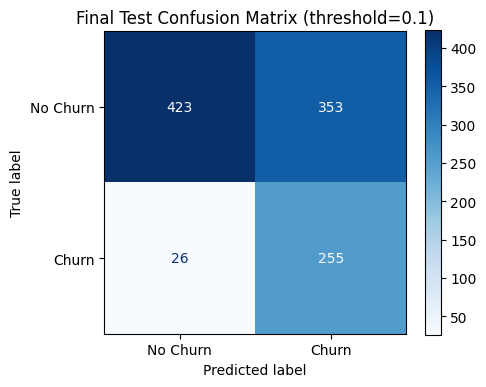

In [4]:
y_true_bin = (y_test == "Yes").astype(int).to_numpy()
y_pred = (test_proba >= threshold).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_true_bin, y_pred, display_labels=["No Churn", "Churn"], ax=ax, cmap="Blues")
ax.set_title(f"Final Test Confusion Matrix (threshold={threshold})")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "15_final_test_confusion_matrix.png", dpi=120)
plt.show()

## 3. Validation vs Test Discussion

Compare ranking metrics (ROC-AUC, PR-AUC, Brier) and threshold-based metrics (Precision, Recall, F1) between validation and test.

**Interpretation guidelines:**
- Small gaps are expected due to sampling variation on ~1k rows per holdout set.
- Large precision/recall shifts may indicate threshold sensitivity or cohort differences — **not** grounds to retune on test.
- Test evaluation is **reporting only**; deployment policy remains frozen.

In [5]:
gap = comparison_df.loc["Test"] - comparison_df.loc["Validation"]
gap_df = gap.to_frame("Test_minus_Validation").round(4)
gap_df

,Test_minus_Validation
Accuracy,0.0088
Precision,0.0040
Recall,-0.0389
F1,-0.0036
ROC_AUC,-0.0121
PR_AUC,0.0140
Brier_Score,0.0041
Predicted_Churners,-30.0000
False_Positives,-20.0000
False_Negatives,11.0000
